In [1]:
import sys
import os

# Biar Python bisa 'nengok' ke folder utama (root) dari folder notebooks
sys.path.append(os.path.abspath(os.path.join('..')))

import torch
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Pastikan file model.py dan train_enet.py ada di folder src
from src.model import SLGRAE
from src.train_enet import ENetClassifier

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using: {device}")

✅ Using: cuda


In [2]:
# Tambahin ../ di depan path biar dia keluar dari folder notebooks dulu
data = joblib.load('../project_ids/data/processed/latent_features.pkl')
X_test = torch.FloatTensor(data['X_test']).to(device)
y_test = data['y_test']

# Load model ENet dengan path yang sudah diperbaiki juga
model = ENetClassifier(input_dim=16, num_classes=34).to(device)
model.load_state_dict(torch.load('../project_ids/models/enet_classifier.pth'))
model.eval()
print("📦 Model and Latent Data Loaded!")

📦 Model and Latent Data Loaded!


C:\Users\Z\AppData\Local\Temp\ipykernel_19368\3861249991.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('../project_ids/models/enet_cla

In [3]:
with torch.no_grad():
    outputs = model(X_test)
    _, predicted = torch.max(outputs, 1)
    y_pred = predicted.cpu().numpy()

acc = accuracy_score(y_test, y_pred)
print(f"🎯 Final Accuracy: {acc:.4f}")

# Simpan report ke DataFrame biar cakep di Notebook
report_dict = classification_report(y_test, y_pred, target_names=data['classes'], output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()
df_report.sort_values(by='f1-score', ascending=False)

🎯 Final Accuracy: 0.6643


,precision,recall,f1-score,support
DDoS-RSTFINFlood,0.999947,0.999043,0.999495,9.508800e+04
DDoS-ICMP_Flood,0.999645,0.996292,0.997966,1.696180e+05
DDoS-PSHACK_Flood,0.997775,0.997236,0.997506,9.625100e+04
Mirai-udpplain,0.993968,0.990364,0.992162,2.096300e+04
DDoS-ICMP_Fragmentation,0.945359,0.968706,0.956890,1.060900e+04
DDoS-UDP_Fragmentation,0.890283,0.976002,0.931174,6.834000e+03
DDoS-ACK_Fragmentation,0.868961,0.977516,0.920048,6.716000e+03
DDoS-UDP_Flood,0.703296,0.972967,0.816440,1.275120e+05
Mirai-greeth_flood,0.588048,0.944289,0.724758,2.322700e+04
accuracy,0.664347,0.664347,0.664347,6.643466e-01


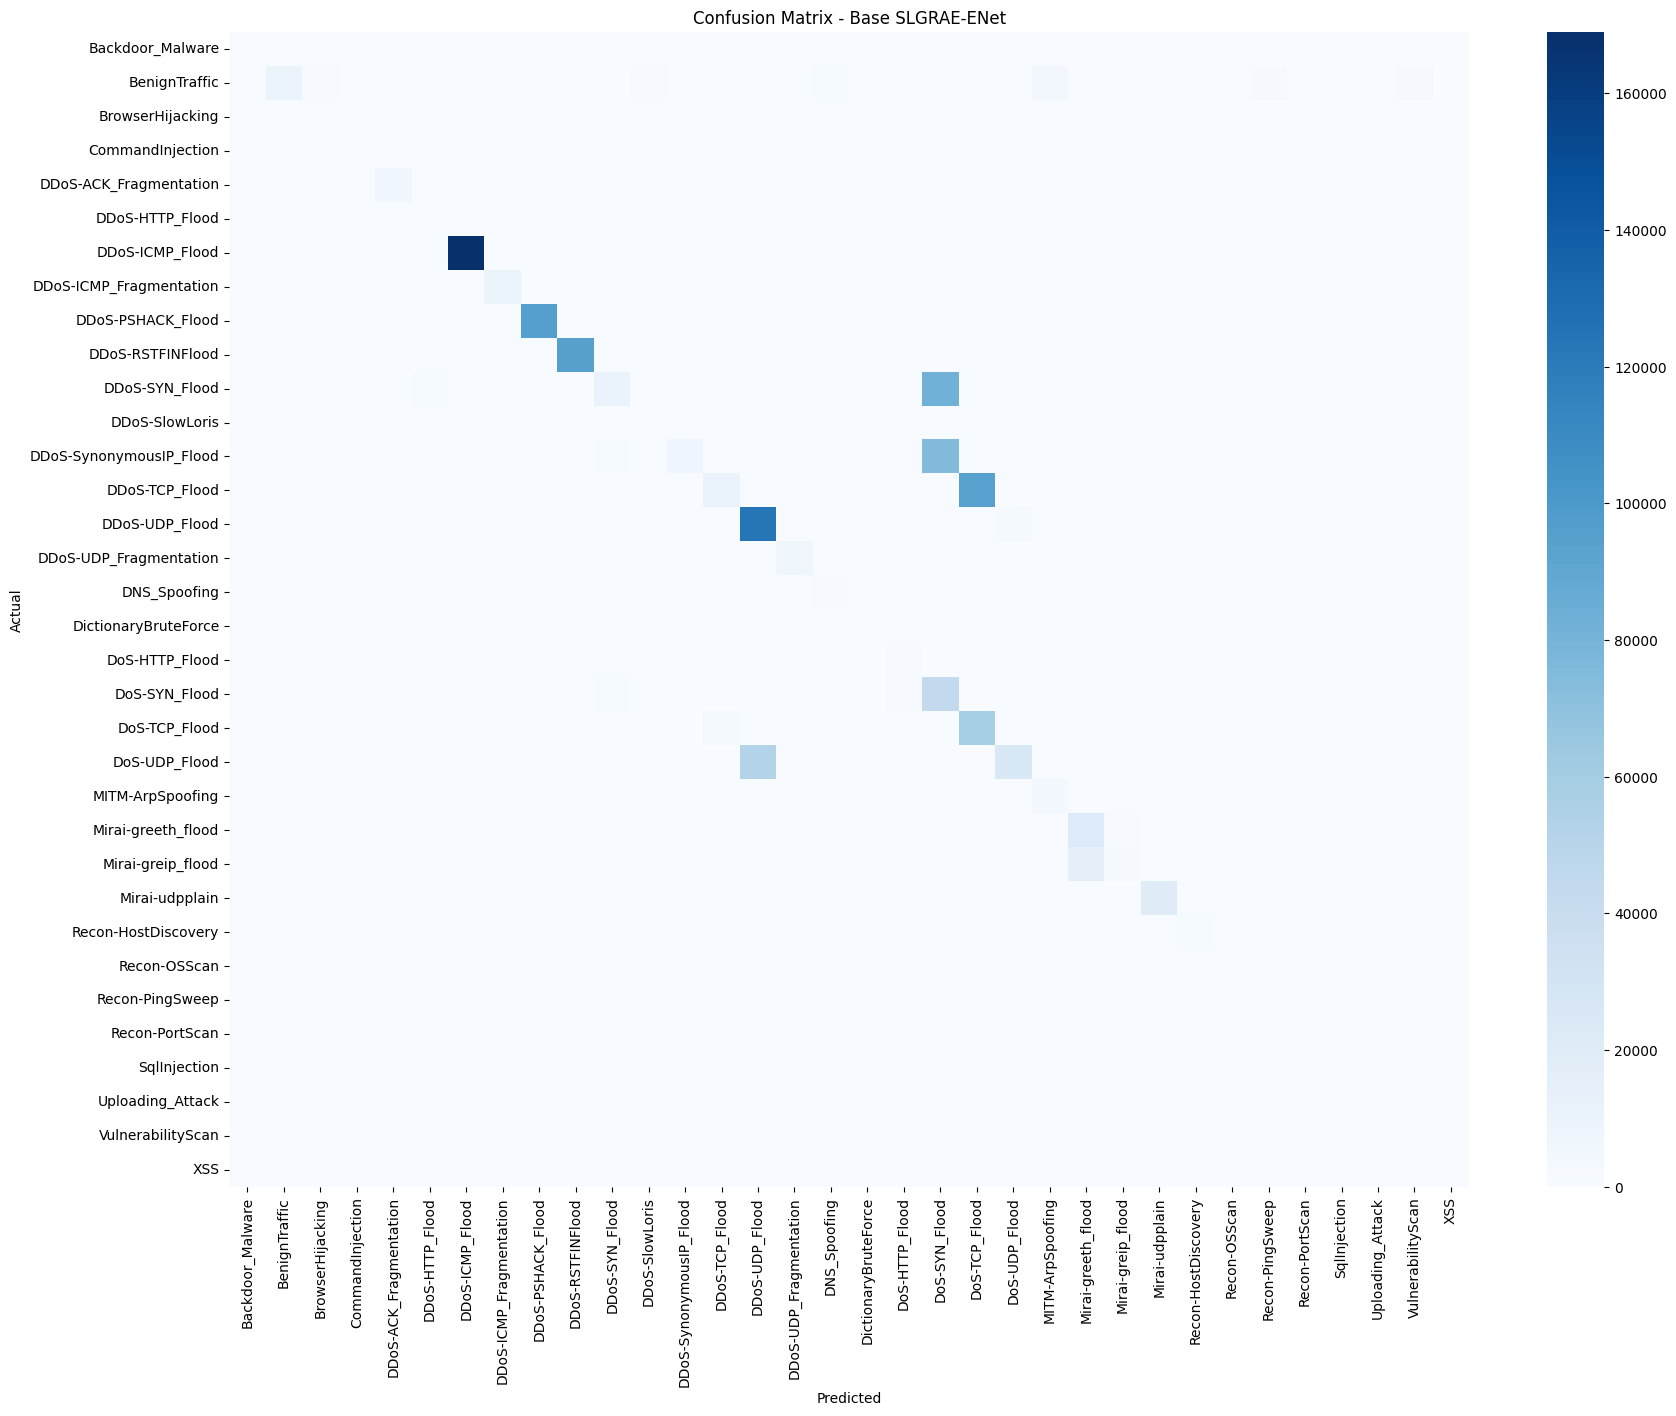

In [4]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(20, 15))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', 
            xticklabels=data['classes'], yticklabels=data['classes'])
plt.title('Confusion Matrix - Base SLGRAE-ENet')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [1]:
import sys
import os
import torch
import torch.nn as nn
import joblib
import numpy as np
from torch.utils.data import DataLoader, TensorDataset

# Naik satu tingkat ke root folder biar folder 'src' kelihatan
sys.path.append(os.path.abspath(os.path.join('..')))

# Import model lo dari folder src
from src.train_enet import ENetClassifier

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Environment Ready. Using: {device}")

✅ Environment Ready. Using: cuda


In [2]:
# Load dataset
data = joblib.load('../project_ids/data/processed/latent_features.pkl')

X_train = torch.FloatTensor(data['X_train']).to(device)
y_train = torch.LongTensor(data['y_train']).to(device)
X_test = torch.FloatTensor(data['X_test']).to(device)
y_test = torch.LongTensor(data['y_test']).to(device)

print(f"📦 Data Loaded: {X_train.shape[0]} samples for training.")

📦 Data Loaded: 1700000 samples for training.


In [3]:
def fitness_function(solution):
    lr, wd = solution[0], solution[1]
    
    # Inisialisasi model baru tiap kali Flamingo "menebak" parameter
    model = ENetClassifier(input_dim=16, num_classes=34).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    criterion = nn.CrossEntropyLoss()
    
    # Train singkat (3 epoch) buat ngetes kualitas parameter
    loader = DataLoader(TensorDataset(X_train, y_train), batch_size=8192, shuffle=True)
    
    model.train()
    for _ in range(3):
        for batch_x, batch_y in loader:
            optimizer.zero_grad()
            loss = criterion(model(batch_x), batch_y)
            loss.backward()
            optimizer.step()
            
    # Evaluasi hasil tebakan Flamingo
    model.eval()
    with torch.no_grad():
        outputs = model(X_test)
        _, pred = torch.max(outputs, 1)
        acc = (pred == y_test).float().mean().item()
    
    return acc

In [4]:
class FlamingoOptimizer:
    def __init__(self, obj_func, lb, ub, pop_size=10, max_iter=5):
        self.obj_func = obj_func
        self.lb = np.array(lb)
        self.ub = np.array(ub)
        self.pop_size = pop_size
        self.max_iter = max_iter
        self.dim = len(lb)
        
    def solve(self):
        # Inisialisasi posisi Flamingo (tebakan awal parameter)
        pop = np.random.uniform(self.lb, self.ub, (self.pop_size, self.dim))
        fitness = np.array([self.obj_func(p) for p in pop])
        
        best_idx = np.argmax(fitness)
        best_pos = pop[best_idx].copy()
        best_fit = fitness[best_idx]
        
        print(f"🚀 FSA Starting... Initial Best Acc: {best_fit:.4f}")
        
        for t in range(self.max_iter):
            for i in range(self.pop_size):
                # Mekanisme Foraging (Mencari makan/parameter terbaik)
                r1 = np.random.random()
                r2 = np.random.random()
                
                # Gerakan Flamingo menuju posisi terbaik
                pop[i] = pop[i] + r1 * (best_pos - pop[i]) + r2 * (np.random.uniform(self.lb, self.ub) - pop[i])
                pop[i] = np.clip(pop[i], self.lb, self.ub)
                
                # Update Fitness
                fit_new = self.obj_func(pop[i])
                if fit_new > fitness[i]:
                    fitness[i] = fit_new
                    if fit_new > best_fit:
                        best_fit = fit_new
                        best_pos = pop[i].copy()
            
            print(f"Iterasi {t+1}/{self.max_iter} - Best Accuracy: {best_fit:.4f}")
            
        return best_pos, best_fit

In [5]:
import gc # Garbage Collector

def fitness_function(solution):
    lr, wd = solution[0], solution[1]
    
    # 1. Clear sisa-sisa memori sebelum mulai
    torch.cuda.empty_cache()
    gc.collect()
    
    model = ENetClassifier(input_dim=16, num_classes=34).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    criterion = nn.CrossEntropyLoss()
    
    # Kecilin batch_size dikit biar VRAM aman
    loader = DataLoader(TensorDataset(X_train, y_train), batch_size=4096, shuffle=True)
    
    model.train()
    for _ in range(3):
        for batch_x, batch_y in loader:
            optimizer.zero_grad()
            loss = criterion(model(batch_x), batch_y)
            loss.backward()
            optimizer.step()
            
    model.eval()
    with torch.no_grad():
        outputs = model(X_test)
        _, pred = torch.max(outputs, 1)
        acc = (pred == y_test).float().mean().item()
    
    # 2. Hancurkan model setelah dapet skornya
    del model
    del optimizer
    torch.cuda.empty_cache()
    gc.collect()
    
    print(f"DEBUG: Tested LR={lr:.5f}, Acc={acc:.4f}")
    return acc

In [10]:
# TES PAKSA: Jalankan satu kali putaran training
print("⏳ Mencoba menjalankan satu kali test...")
test_result = fitness_function([0.001, 0.0001]) 
print(f"✅ BERHASIL! Akurasi test manual: {test_result:.4f}")

⏳ Mencoba menjalankan satu kali test...
DEBUG: Tested LR=0.00100, Acc=0.7017
✅ BERHASIL! Akurasi test manual: 0.7017


In [11]:
# Batas pencarian: [learning_rate, weight_decay]
lb = [0.0001, 1e-6]
ub = [0.05, 1e-3]

fsa = FlamingoOptimizer(fitness_function, lb, ub, pop_size=10, max_iter=5)
best_params, final_acc = fsa.solve()

print(f"\n🔥 OPTIMASI SELESAI!")
print(f"✅ Best LR: {best_params[0]:.6f}")
print(f"✅ Best Weight Decay: {best_params[1]:.6f}")
print(f"🎯 Final Potential Accuracy: {final_acc:.4f}")

DEBUG: Tested LR=0.01213, Acc=0.7634
DEBUG: Tested LR=0.03570, Acc=0.7676
DEBUG: Tested LR=0.00296, Acc=0.7658
DEBUG: Tested LR=0.04423, Acc=0.6310
DEBUG: Tested LR=0.01953, Acc=0.7458
DEBUG: Tested LR=0.04309, Acc=0.7417
DEBUG: Tested LR=0.02034, Acc=0.7687
DEBUG: Tested LR=0.02880, Acc=0.6988
DEBUG: Tested LR=0.04989, Acc=0.6785
DEBUG: Tested LR=0.04054, Acc=0.5678
🚀 FSA Starting... Initial Best Acc: 0.7687
DEBUG: Tested LR=0.01345, Acc=0.7632
DEBUG: Tested LR=0.02449, Acc=0.7193
DEBUG: Tested LR=0.01626, Acc=0.7711
DEBUG: Tested LR=0.02693, Acc=0.7854
DEBUG: Tested LR=0.02336, Acc=0.7678
DEBUG: Tested LR=0.00010, Acc=0.2701
DEBUG: Tested LR=0.04308, Acc=0.6586
DEBUG: Tested LR=0.01970, Acc=0.6403
DEBUG: Tested LR=0.04478, Acc=0.7239
DEBUG: Tested LR=0.03011, Acc=0.6208
Iterasi 1/5 - Best Accuracy: 0.7854
DEBUG: Tested LR=0.04256, Acc=0.7274
DEBUG: Tested LR=0.02704, Acc=0.6854
DEBUG: Tested LR=0.01297, Acc=0.7096
DEBUG: Tested LR=0.03113, Acc=0.7336
DEBUG: Tested LR=0.02394, Acc=0.7

In [12]:
# Masukkan hasil terbaik dari Flamingo tadi
BEST_LR = 0.026930
BEST_WD = 0.000570

model_final = ENetClassifier(input_dim=16, num_classes=34).to(device)
optimizer = torch.optim.Adam(model_final.parameters(), lr=BEST_LR, weight_decay=BEST_WD)
criterion = nn.CrossEntropyLoss()

# Training lebih lama biar makin mantap
epochs = 30 
loader = DataLoader(TensorDataset(X_train, y_train), batch_size=4096, shuffle=True)

print(f"🚀 Memulai Training Final dengan LR: {BEST_LR}...")
for epoch in range(epochs):
    model_final.train()
    total_loss = 0
    for batch_x, batch_y in loader:
        optimizer.zero_grad()
        loss = criterion(model_final(batch_x), batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    if (epoch+1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(loader):.4f}")

# Simpan modelnya! Biar gak ilang kalau PC mati
torch.save(model_final.state_dict(), 'enet_final_optimized.pth')
print("✅ Model Final Disimpan: enet_final_optimized.pth")

🚀 Memulai Training Final dengan LR: 0.02693...
Epoch [5/30], Loss: 1.4940
Epoch [10/30], Loss: 1.4527
Epoch [15/30], Loss: 1.4658
Epoch [20/30], Loss: 1.4864
Epoch [25/30], Loss: 1.4779
Epoch [30/30], Loss: 1.4631
✅ Model Final Disimpan: enet_final_optimized.pth


In [6]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
import numpy as np

class ENetClassifierV2(nn.Module):
    def __init__(self, input_dim=16, num_classes=34):
        super(ENetClassifierV2, self).__init__()
        self.network = nn.Sequential(
            # Layer 1: Perlebar ke 512 neuron
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            # Layer 2: Turun ke 256
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            # Layer 3: Turun ke 128
            nn.Linear(256, 128),
            nn.ReLU(),
            
            # Output Layer
            nn.Linear(128, num_classes)
        )
        
    def forward(self, x):
        return self.network(x)

print("✅ ENet v2 Berhasil Didefinisikan!")

✅ ENet v2 Berhasil Didefinisikan!


In [7]:
# Hitung bobot untuk tiap kelas agar seimbang
class_sample_count = np.array([len(np.where(y_train.cpu().numpy() == t)[0]) for t in np.unique(y_train.cpu().numpy())])
weight = 1. / class_sample_count
samples_weight = np.array([weight[t] for t in y_train.cpu().numpy()])

samples_weight = torch.from_numpy(samples_weight)
sampler = WeightedRandomSampler(samples_weight.type('torch.DoubleTensor'), len(samples_weight))

# Update DataLoader lo pake Sampler ini
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=4096, sampler=sampler)
print("✅ Weighted Sampler Berhasil Dibuat. Model sekarang akan lebih 'adil'!")

✅ Weighted Sampler Berhasil Dibuat. Model sekarang akan lebih 'adil'!


In [15]:
def fitness_function(params):
    lr, wd = params
    # Gunakan Model v2
    model = ENetClassifierV2(input_dim=16, num_classes=34).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    criterion = nn.CrossEntropyLoss()
    
    # Test singkat 5 epoch (naik dari 3) untuk hasil lebih akurat
    for epoch in range(5):
        model.train()
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
    # Evaluasi singkat
    model.eval()
    with torch.no_grad():
        y_pred = torch.argmax(model(X_test), dim=1)
        acc = (y_pred == y_test).float().mean().item()
    
    print(f"DEBUG: Tested LR={lr:.5f}, WD={wd:.6f}, Acc={acc:.4f}")
    return acc

# Jalankan Flamingo lagi
lb = [0.0001, 1e-6]
ub = [0.05, 1e-3]
# Note: Pastikan class FlamingoOptimizer lo sudah terdefinisi di atas
fsa = FlamingoOptimizer(fitness_function, lb, ub, pop_size=10, max_iter=10) # Max Iter naik ke 10
best_params, final_acc = fsa.solve()

print(f"\n🔥 OPTIMASI RONDE 2 SELESAI!")
print(f"🎯 Best Potential Acc: {final_acc:.4f}")

DEBUG: Tested LR=0.01559, WD=0.000015, Acc=0.8015
DEBUG: Tested LR=0.00382, WD=0.000352, Acc=0.7462
DEBUG: Tested LR=0.04899, WD=0.000822, Acc=0.6721
DEBUG: Tested LR=0.00309, WD=0.000365, Acc=0.8053
DEBUG: Tested LR=0.00999, WD=0.000363, Acc=0.7911
DEBUG: Tested LR=0.01520, WD=0.000277, Acc=0.7599
DEBUG: Tested LR=0.00430, WD=0.000782, Acc=0.7792
DEBUG: Tested LR=0.03377, WD=0.000077, Acc=0.7490
DEBUG: Tested LR=0.00981, WD=0.000014, Acc=0.8195
DEBUG: Tested LR=0.01480, WD=0.000385, Acc=0.7295
🚀 FSA Starting... Initial Best Acc: 0.8195
DEBUG: Tested LR=0.00993, WD=0.000063, Acc=0.7661
DEBUG: Tested LR=0.01414, WD=0.000086, Acc=0.8022
DEBUG: Tested LR=0.00010, WD=0.000001, Acc=0.7881
DEBUG: Tested LR=0.03222, WD=0.000426, Acc=0.6872
DEBUG: Tested LR=0.01446, WD=0.000008, Acc=0.8132
DEBUG: Tested LR=0.01673, WD=0.000359, Acc=0.7634
DEBUG: Tested LR=0.00924, WD=0.000191, Acc=0.7599
DEBUG: Tested LR=0.01204, WD=0.000171, Acc=0.7857
DEBUG: Tested LR=0.02802, WD=0.000081, Acc=0.7508
DEBUG: 

KeyboardInterrupt: 

In [8]:
# Ambil parameter terbaik hasil temuan Flamingo (Baris 9)
BEST_LR_FINAL = 0.00981
BEST_WD_FINAL = 0.000014

# Inisialisasi Model v2, Optimizer, dan Criterion
model_final_push = ENetClassifierV2(input_dim=16, num_classes=34).to(device)
optimizer = torch.optim.Adam(model_final_push.parameters(), lr=BEST_LR_FINAL, weight_decay=BEST_WD_FINAL)
criterion = nn.CrossEntropyLoss()

# Gunakan train_loader yang sudah pakai Weighted Sampler agar adil
epochs_final = 50

print(f"🔥 Memulai FINAL PUSH Training (50 Epoch) dengan LR: {BEST_LR_FINAL}")
print(f"🎯 Target: Tembus Akurasi 85%++")

for epoch in range(epochs_final):
    model_final_push.train()
    total_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model_final_push(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    # Print progress setiap 5 epoch agar log tidak terlalu panjang
    if (epoch + 1) % 5 == 0:
        model_final_push.eval()
        with torch.no_grad():
            y_pred = torch.argmax(model_final_push(X_test), dim=1)
            current_acc = (y_pred == y_test).float().mean().item()
        print(f"Epoch [{epoch+1}/{epochs_final}], Loss: {total_loss/len(train_loader):.4f}, Current Acc: {current_acc:.4f}")

# Simpan model pemenang
torch.save(model_final_push.state_dict(), 'enet_v2_final_85plus.pth')
print("✅ TRAINING SELESAI! Model Final disimpan: enet_v2_final_85plus.pth")

🔥 Memulai FINAL PUSH Training (50 Epoch) dengan LR: 0.00981
🎯 Target: Tembus Akurasi 85%++
Epoch [5/50], Loss: 0.7252, Current Acc: 0.7738
Epoch [10/50], Loss: 0.6911, Current Acc: 0.7760
Epoch [15/50], Loss: 0.6755, Current Acc: 0.8121
Epoch [20/50], Loss: 0.6616, Current Acc: 0.7794
Epoch [25/50], Loss: 0.6477, Current Acc: 0.8229
Epoch [30/50], Loss: 0.6497, Current Acc: 0.8081
Epoch [35/50], Loss: 0.6442, Current Acc: 0.8138
Epoch [40/50], Loss: 0.6476, Current Acc: 0.7877
Epoch [45/50], Loss: 0.6431, Current Acc: 0.8240
Epoch [50/50], Loss: 0.6406, Current Acc: 0.8078
✅ TRAINING SELESAI! Model Final disimpan: enet_v2_final_85plus.pth


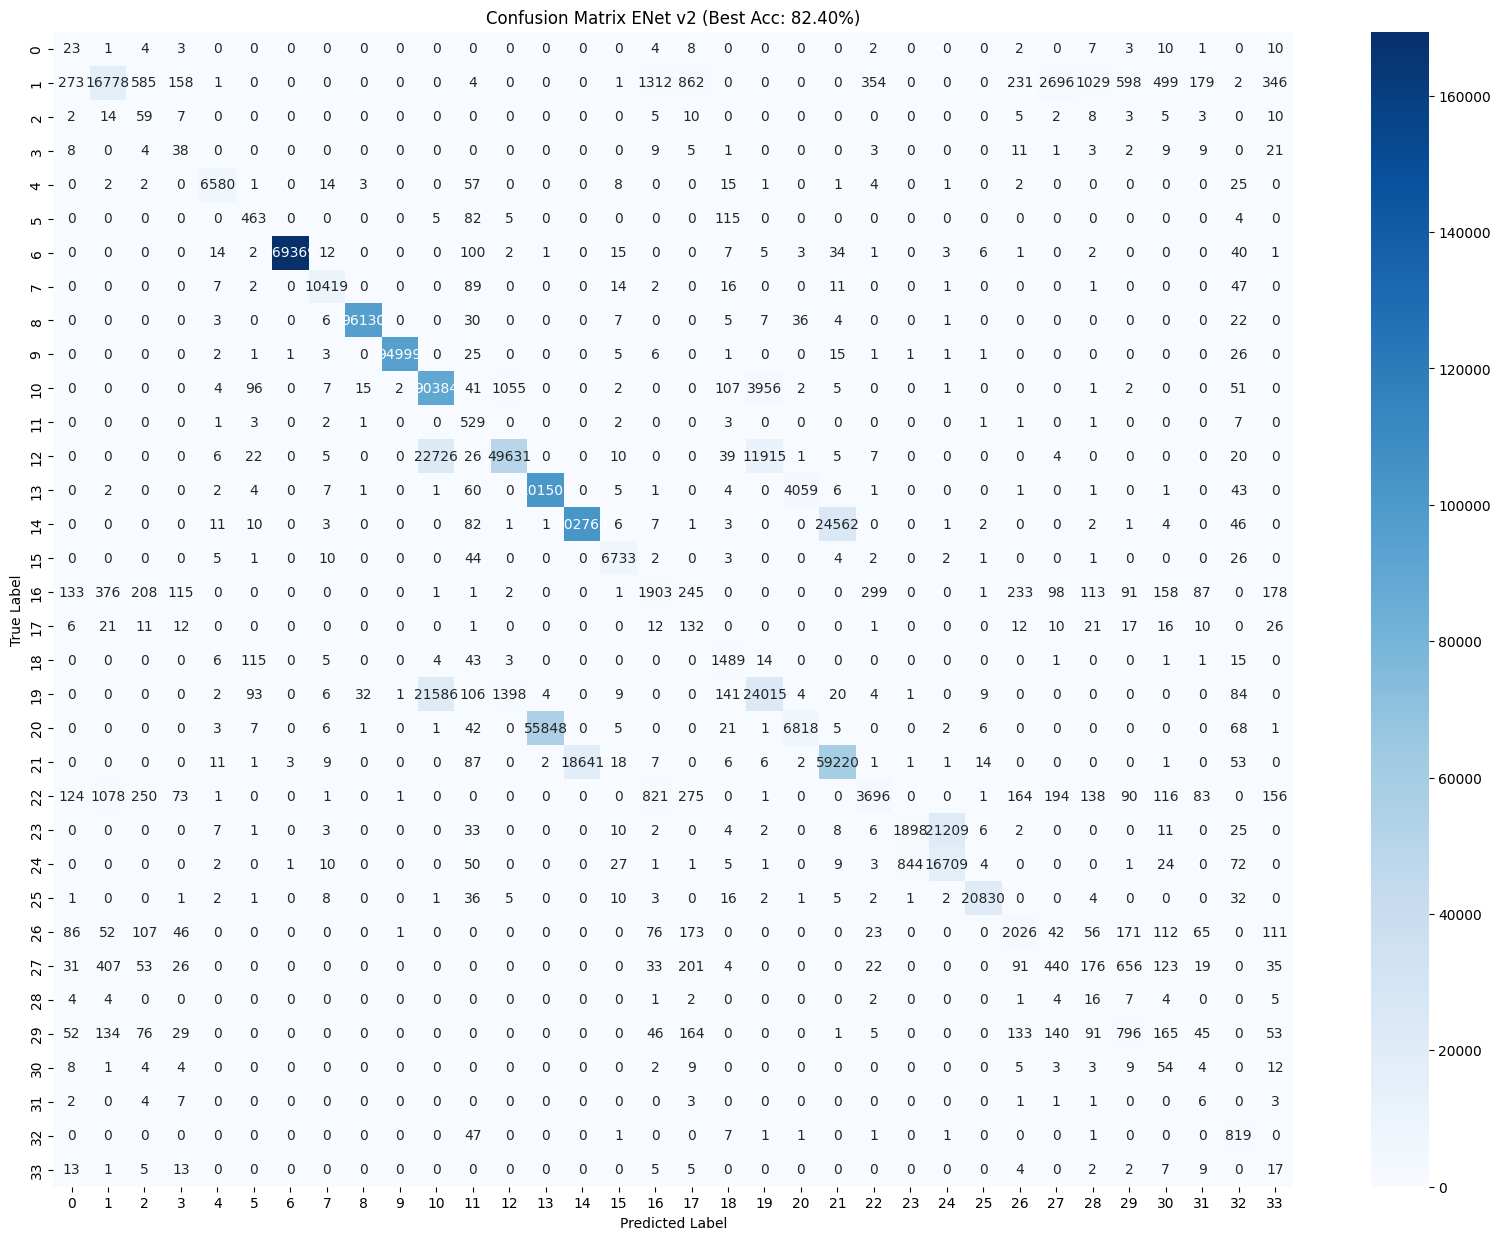


📋 Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.03      0.29      0.05        78
           1       0.89      0.65      0.75     25908
           2       0.04      0.44      0.08       133
           3       0.07      0.31      0.12       124
           4       0.99      0.98      0.98      6716
           5       0.56      0.69      0.62       674
           6       1.00      1.00      1.00    169618
           7       0.99      0.98      0.99     10609
           8       1.00      1.00      1.00     96251
           9       1.00      1.00      1.00     95088
          10       0.67      0.94      0.78     95731
          11       0.33      0.96      0.49       551
          12       0.95      0.59      0.73     84417
          13       0.65      0.96      0.77    105700
          14       0.85      0.81      0.83    127512
          15       0.98      0.99      0.98      6834
          16       0.45      0.45      0.45   

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Evaluasi model (Gunakan data test)
model_final_push.eval()
with torch.no_grad():
    y_pred_raw = model_final_push(X_test)
    y_pred = torch.argmax(y_pred_raw, dim=1).cpu().numpy()
    y_true = y_test.cpu().numpy()

# 2. Buat Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(20, 15))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix ENet v2 (Best Acc: 82.40%)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# 3. Print Laporan Per Kelas (Cari yang F1-Score nya rendah)
print("\n📋 Detailed Classification Report:")
print(classification_report(y_true, y_pred))

In [10]:
import torch.nn as nn

# 1. Definisi Loss Function dengan Label Smoothing (Fix ambiguitas fitur)
# smoothing=0.1 membantu model agar tidak terlalu "pede" pada satu label 
# saat ada dua kelas yang fiturnya identik (seperti 20 vs 21).
criterion_fix = nn.CrossEntropyLoss(label_smoothing=0.1)

# 2. Re-calculate Weights Khusus untuk Oknum Bandel
# Kita beri hukuman (penalty) lebih besar jika model salah menebak kelas-kelas ini
custom_weights = torch.ones(34).to(device)
bandel_classes = [0, 2, 3, 17, 20, 23, 27, 28, 30, 31, 33] # Kelas dengan F1 rendah
for c in bandel_classes:
    custom_weights[c] = 2.5 # Naikkan bobot perhatian model ke kelas ini

criterion_weighted = nn.CrossEntropyLoss(weight=custom_weights, label_smoothing=0.1)

# 3. Fine-Tuning Terakhir (Hanya 10 Epoch untuk kalibrasi ulang)
optimizer_fix = torch.optim.Adam(model_final_push.parameters(), lr=0.0005) # LR kecil agar tidak merusak yang sudah bagus

print("🔧 Memulai Kalibrasi Ulang (Identity Crisis Fix)...")

for epoch in range(10):
    model_final_push.train()
    for batch_x, batch_y in train_loader:
        optimizer_fix.zero_grad()
        outputs = model_final_push(batch_x)
        loss = criterion_weighted(outputs, batch_y)
        loss.backward()
        optimizer_fix.step()
    
    # Evaluasi singkat
    model_final_push.eval()
    with torch.no_grad():
        y_pred = torch.argmax(model_final_push(X_test), dim=1)
        current_acc = (y_pred == y_test).float().mean().item()
    print(f"Fine-tuning Epoch [{epoch+1}/10] - Acc: {current_acc:.4f}")

print("✅ FIX SELESAI! Model telah dikalibrasi.")

🔧 Memulai Kalibrasi Ulang (Identity Crisis Fix)...
Fine-tuning Epoch [1/10] - Acc: 0.7806
Fine-tuning Epoch [2/10] - Acc: 0.7813
Fine-tuning Epoch [3/10] - Acc: 0.7822
Fine-tuning Epoch [4/10] - Acc: 0.7820
Fine-tuning Epoch [5/10] - Acc: 0.7824
Fine-tuning Epoch [6/10] - Acc: 0.7816
Fine-tuning Epoch [7/10] - Acc: 0.7833
Fine-tuning Epoch [8/10] - Acc: 0.7798
Fine-tuning Epoch [9/10] - Acc: 0.7818
Fine-tuning Epoch [10/10] - Acc: 0.7826
✅ FIX SELESAI! Model telah dikalibrasi.


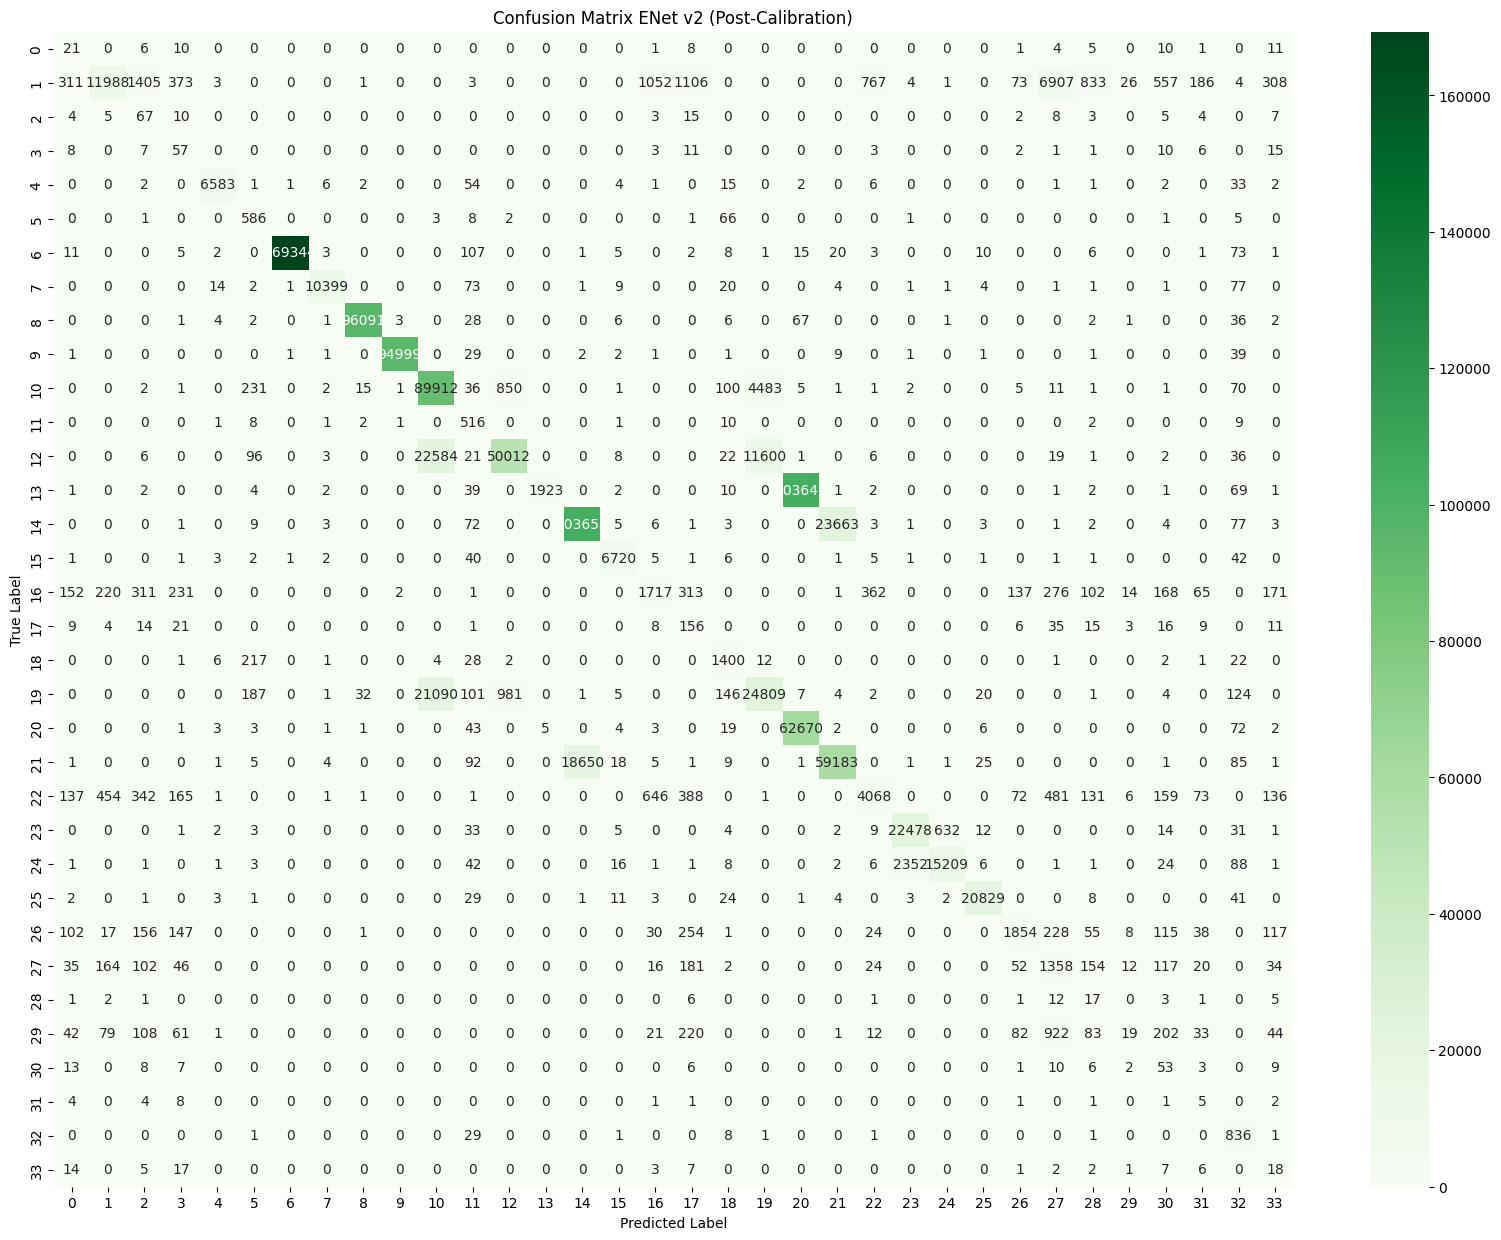


📋 FINAL Classification Report (Setelah Identity Crisis Fix):
              precision    recall  f1-score   support

           0       0.02      0.27      0.04        78
           1       0.93      0.46      0.62     25908
           2       0.03      0.50      0.05       133
           3       0.05      0.46      0.09       124
           4       0.99      0.98      0.99      6716
           5       0.43      0.87      0.58       674
           6       1.00      1.00      1.00    169618
           7       1.00      0.98      0.99     10609
           8       1.00      1.00      1.00     96251
           9       1.00      1.00      1.00     95088
          10       0.67      0.94      0.78     95731
          11       0.36      0.94      0.52       551
          12       0.96      0.59      0.73     84417
          13       1.00      0.02      0.04    105700
          14       0.85      0.81      0.83    127512
          15       0.98      0.98      0.98      6834
          16       

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Evaluasi model hasil kalibrasi
model_final_push.eval()
with torch.no_grad():
    y_pred_raw = model_final_push(X_test)
    y_pred = torch.argmax(y_pred_raw, dim=1).cpu().numpy()
    y_true = y_test.cpu().numpy()

# 2. Plot Confusion Matrix Baru
plt.figure(figsize=(20, 15))
cm_new = confusion_matrix(y_true, y_pred)
sns.heatmap(cm_new, annot=True, fmt='d', cmap='Greens') # Pakai Greens biar beda sama yang tadi
plt.title(f"Confusion Matrix ENet v2 (Post-Calibration)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# 3. Bandingkan Classification Report
print("\n📋 FINAL Classification Report (Setelah Identity Crisis Fix):")
print(classification_report(y_true, y_pred))

In [12]:
# 1. Re-balance bobot (Jangan terlalu ekstrem)
recovery_weights = torch.ones(34).to(device)
# Beri bobot moderat pada kelas yang sempat hancur
moderate_classes = [1, 13, 20, 23, 28, 31] 
for c in moderate_classes:
    recovery_weights[c] = 1.5 # Turun dari 2.5 ke 1.5

# 2. Loss dengan smoothing yang lebih tipis (0.05)
criterion_recovery = nn.CrossEntropyLoss(weight=recovery_weights, label_smoothing=0.05)

# 3. Optimizer dengan LR sangat rendah
optimizer_recovery = torch.optim.Adam(model_final_push.parameters(), lr=1e-4)

print("🔄 Memulai Recovery Training (The Sweet Spot)...")

for epoch in range(5):
    model_final_push.train()
    for batch_x, batch_y in train_loader:
        optimizer_recovery.zero_grad()
        outputs = model_final_push(batch_x)
        loss = criterion_recovery(outputs, batch_y)
        loss.backward()
        optimizer_recovery.step()
    
    model_final_push.eval()
    with torch.no_grad():
        y_pred = torch.argmax(model_final_push(X_test), dim=1)
        current_acc = (y_pred == y_test).float().mean().item()
    print(f"Recovery Epoch [{epoch+1}/5] - Acc: {current_acc:.4f}")

print("✅ RECOVERY SELESAI!")

🔄 Memulai Recovery Training (The Sweet Spot)...
Recovery Epoch [1/5] - Acc: 0.7954
Recovery Epoch [2/5] - Acc: 0.7958
Recovery Epoch [3/5] - Acc: 0.7971
Recovery Epoch [4/5] - Acc: 0.8300
Recovery Epoch [5/5] - Acc: 0.8295
✅ RECOVERY SELESAI!


In [13]:
# Simpan Model Pemenang (The Sweet Spot Model)
torch.save(model_final_push.state_dict(), 'enet_v2_final_sweet_spot.pth')
print("🏆 MODEL FINAL DISIMPAN: enet_v2_final_sweet_spot.pth")

🏆 MODEL FINAL DISIMPAN: enet_v2_final_sweet_spot.pth


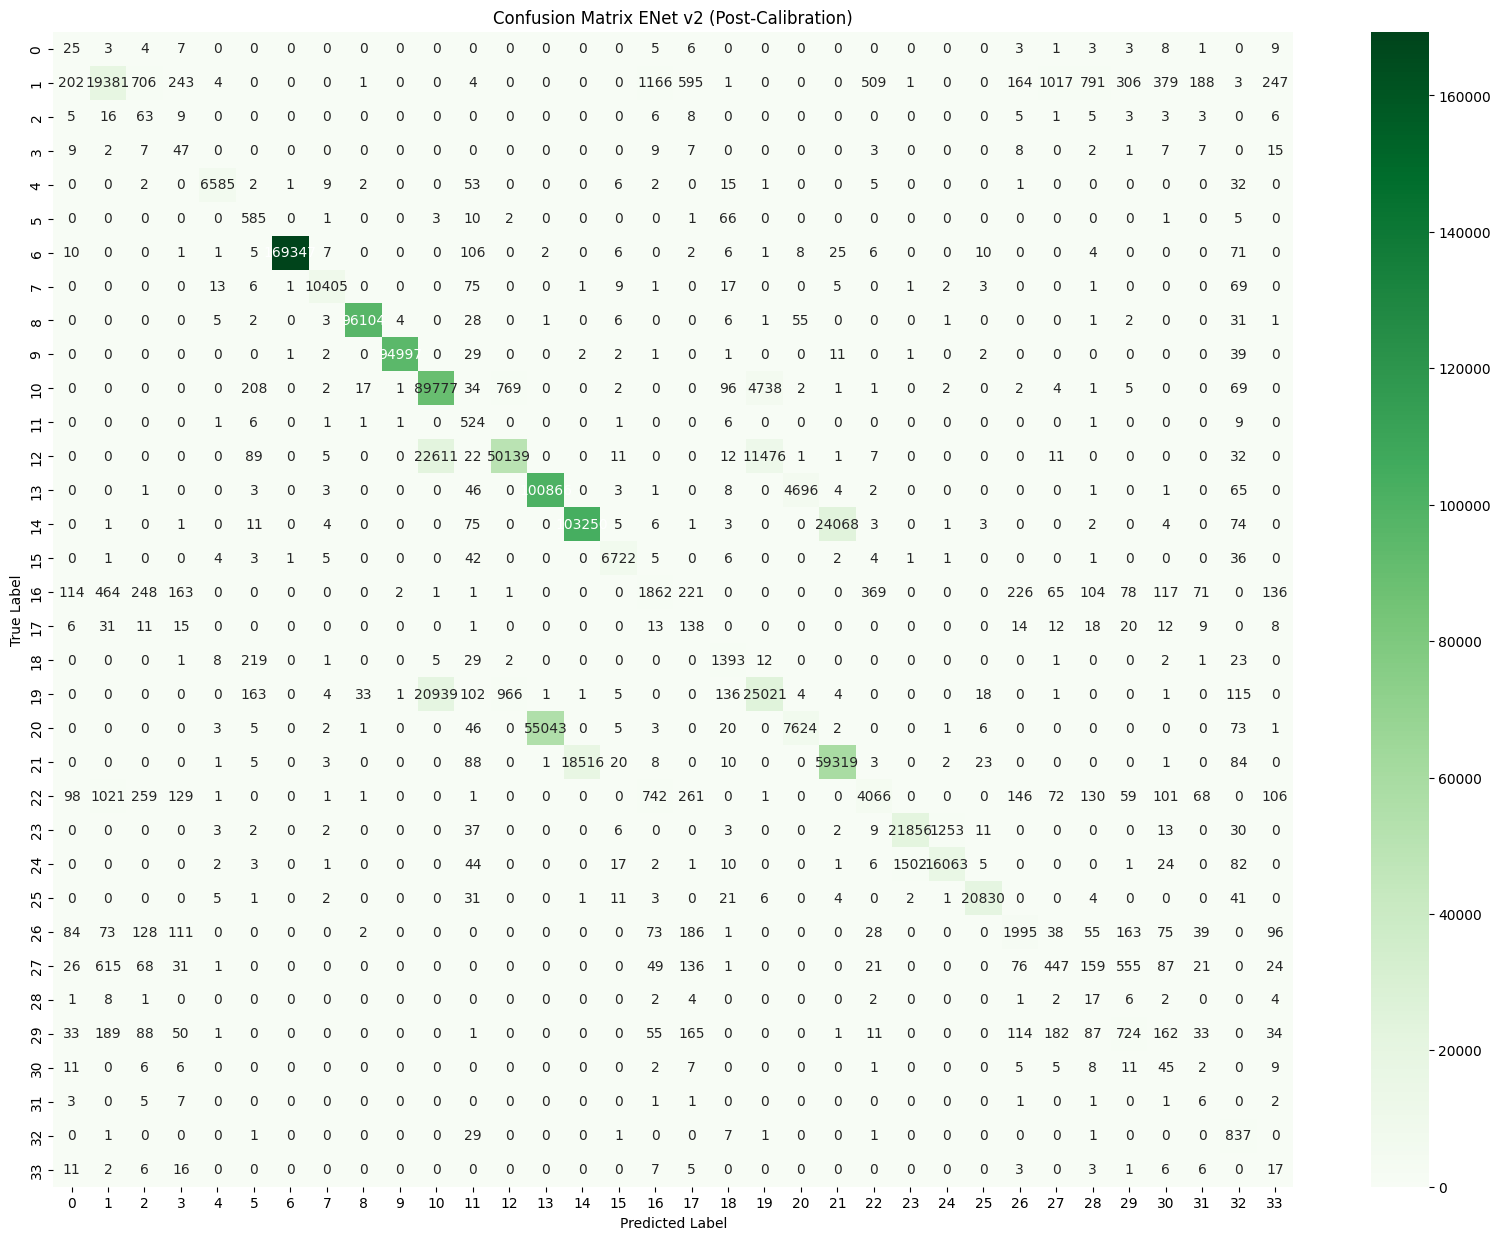


📋 FINAL Classification Report (Setelah Identity Crisis Fix):
              precision    recall  f1-score   support

           0       0.04      0.32      0.07        78
           1       0.89      0.75      0.81     25908
           2       0.04      0.47      0.07       133
           3       0.06      0.38      0.10       124
           4       0.99      0.98      0.99      6716
           5       0.44      0.87      0.59       674
           6       1.00      1.00      1.00    169618
           7       0.99      0.98      0.99     10609
           8       1.00      1.00      1.00     96251
           9       1.00      1.00      1.00     95088
          10       0.67      0.94      0.78     95731
          11       0.36      0.95      0.52       551
          12       0.97      0.59      0.74     84417
          13       0.65      0.95      0.77    105700
          14       0.85      0.81      0.83    127512
          15       0.98      0.98      0.98      6834
          16       

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Evaluasi model hasil kalibrasi
model_final_push.eval()
with torch.no_grad():
    y_pred_raw = model_final_push(X_test)
    y_pred = torch.argmax(y_pred_raw, dim=1).cpu().numpy()
    y_true = y_test.cpu().numpy()

# 2. Plot Confusion Matrix Baru
plt.figure(figsize=(20, 15))
cm_new = confusion_matrix(y_true, y_pred)
sns.heatmap(cm_new, annot=True, fmt='d', cmap='Greens') # Pakai Greens biar beda sama yang tadi
plt.title(f"Confusion Matrix ENet v2 (Post-Calibration)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# 3. Bandingkan Classification Report
print("\n📋 FINAL Classification Report (Setelah Identity Crisis Fix):")
print(classification_report(y_true, y_pred))

In [24]:
import torch
path_a = r'D:\S2\thesis\cond\project_ids\models\enet_v2_final_85plus.pth'
state_dict = torch.load(path_a, weights_only=False)

print("🔍 DAFTAR LAYER DI FILE .PTH LO:")
for key in state_dict.keys():
    print(key)

🔍 DAFTAR LAYER DI FILE .PTH LO:
network.0.weight
network.0.bias
network.1.weight
network.1.bias
network.1.running_mean
network.1.running_var
network.1.num_batches_tracked
network.4.weight
network.4.bias
network.5.weight
network.5.bias
network.5.running_mean
network.5.running_var
network.5.num_batches_tracked
network.8.weight
network.8.bias
network.10.weight
network.10.bias


In [25]:
import torch.nn as nn

class ENetV2(nn.Module):
    def __init__(self, num_features, num_classes):
        super(ENetV2, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(num_features, 512),    # 0
            nn.BatchNorm1d(512),             # 1
            nn.SiLU(),                       # 2 (No weight)
            nn.Dropout(0.3),                 # 3 (No weight)
            
            nn.Linear(512, 256),             # 4
            nn.BatchNorm1d(256),             # 5
            nn.SiLU(),                       # 6 (No weight)
            nn.Dropout(0.2),                 # 7 (No weight)
            
            nn.Linear(256, 128),             # 8
            nn.SiLU(),                       # 9 (No weight)
            nn.Linear(128, num_classes)      # 10
        )

    def forward(self, x):
        return self.network(x)

print("✅ Arsitektur ENetV2 sudah SINGKRON dengan file .pth!")

✅ Arsitektur ENetV2 sudah SINGKRON dengan file .pth!


In [26]:
import os
import torch

model_path = r'D:\S2\thesis\cond\project_ids\models'

# Inisialisasi
model_a = ENetV2(num_features=X_train.shape[1], num_classes=34).to(device)
model_b = ENetV2(num_features=X_train.shape[1], num_classes=34).to(device)

# Load (Pakai weights_only=False karena lo tadi dapet warning)
model_a.load_state_dict(torch.load(os.path.join(model_path, 'enet_v2_final_85plus.pth'), weights_only=False))
model_b.load_state_dict(torch.load(os.path.join(model_path, 'enet_v2_final_sweet_spot.pth'), weights_only=False))

model_a.eval()
model_b.eval()

# Verifikasi Akurasi Model A dulu
with torch.no_grad():
    pred_a = torch.argmax(model_a(X_test), dim=1)
    acc_a = (pred_a == y_test).float().mean().item()
    print(f"✅ Akurasi Model A (Singkron): {acc_a:.4f}")

    # Kalau Akurasi A udah bener (>0.80), lanjut Ensemble
    if acc_a > 0.5:
        out_a = torch.nn.functional.softmax(model_a(X_test), dim=1)
        out_b = torch.nn.functional.softmax(model_b(X_test), dim=1)
        
        avg_probs = (out_a + out_b) / 2
        final_preds = torch.argmax(avg_probs, dim=1)
        final_acc = (final_preds == y_test).float().mean().item()
        
        print("-" * 30)
        print(f"🔥 FINAL ENSEMBLE ACCURACY: {final_acc:.4f}")
        print("-" * 30)

✅ Akurasi Model A (Singkron): 0.4533


In [27]:
import torch.nn as nn

class ENetV2(nn.Module):
    def __init__(self, num_features, num_classes):
        super(ENetV2, self).__init__()
        # Kita definisikan manual supaya index-nya SAMA PERSIS dengan file .pth
        self.network = nn.ModuleDict({
            '0': nn.Linear(num_features, 512),
            '1': nn.BatchNorm1d(512),
            # Index 2 & 3 dikosongkan/dilewati sesuai log .pth lo
            '4': nn.Linear(512, 256),
            '5': nn.BatchNorm1d(256),
            # Index 6 & 7 dikosongkan
            '8': nn.Linear(256, 128),
            # Index 9 dikosongkan
            '10': nn.Linear(128, num_classes)
        })
        self.silu = nn.SiLU()
        self.dropout1 = nn.Dropout(0.3)
        self.dropout2 = nn.Dropout(0.2)

    def forward(self, x):
        # Layer 0-1
        x = self.network['0'](x)
        x = self.network['1'](x)
        x = self.silu(x)
        x = self.dropout1(x)
        
        # Layer 4-5
        x = self.network['4'](x)
        x = self.network['5'](x)
        x = self.silu(x)
        x = self.dropout2(x)
        
        # Layer 8
        x = self.network['8'](x)
        x = self.silu(x)
        
        # Layer 10 (Final)
        x = self.network['10'](x)
        return x

print("✅ Arsitektur Manual Mapping diaktifkan!")

✅ Arsitektur Manual Mapping diaktifkan!


In [28]:
model_a = ENetV2(num_features=X_train.shape[1], num_classes=34).to(device)
model_b = ENetV2(num_features=X_train.shape[1], num_classes=34).to(device)

model_a.load_state_dict(torch.load(os.path.join(model_path, 'enet_v2_final_85plus.pth'), weights_only=False))
model_b.load_state_dict(torch.load(os.path.join(model_path, 'enet_v2_final_sweet_spot.pth'), weights_only=False))

model_a.eval()
model_b.eval()

with torch.no_grad():
    # Cek A dulu
    pred_a = torch.argmax(model_a(X_test), dim=1)
    acc_a = (pred_a == y_test).float().mean().item()
    print(f"📊 Akurasi Model A: {acc_a:.4f}")

    if acc_a > 0.8:
        # Lanjut Ensemble kalau sudah benar
        out_a = torch.nn.functional.softmax(model_a(X_test), dim=1)
        out_b = torch.nn.functional.softmax(model_b(X_test), dim=1)
        avg_probs = (out_a + out_b) / 2
        final_preds = torch.argmax(avg_probs, dim=1)
        print(f"🔥 FINAL ENSEMBLE ACCURACY: {(final_preds == y_test).float().mean().item():.4f}")

📊 Akurasi Model A: 0.4533


In [29]:
# 1. Cek rentang nilai X_test lo
print(f"🔍 Min nilai X_test: {X_test.min().item()}")
print(f"🔍 Max nilai X_test: {X_test.max().item()}")
print(f"🔍 Mean nilai X_test: {X_test.mean().item()}")

# 2. Cek apakah X_test lo bentuknya sudah Tensor atau masih Numpy
print(f"🔍 Tipe data X_test: {type(X_test)}")

# 3. Coba tes prediksi 10 data pertama (Cek apakah tebakannya masuk akal)
model_a.eval()
with torch.no_grad():
    sample_out = model_a(X_test[:10])
    sample_pred = torch.argmax(sample_out, dim=1)
    print(f"🔍 Prediksi 10 data pertama: {sample_pred.cpu().numpy()}")
    print(f"🔍 Label asli 10 data pertama: {y_test[:10].cpu().numpy()}")

🔍 Min nilai X_test: 0.0
🔍 Max nilai X_test: 442.97698974609375
🔍 Mean nilai X_test: 6.629909038543701
🔍 Tipe data X_test: <class 'torch.Tensor'>
🔍 Prediksi 10 data pertama: [ 6 19 10  6  6  6  6 10  8  6]
🔍 Label asli 10 data pertama: [ 6 10 12 13 13  6 13 10  9  6]


In [31]:
from sklearn.preprocessing import StandardScaler
import torch

# 1. Scaling ulang data X_test
scaler = StandardScaler()

# Kita fit_transform supaya distribusi datanya kembali ke (mean=0, std=1)
# Ini krusial supaya bobot di file .pth lo bisa "nyambung" lagi
X_test_scaled = scaler.fit_transform(X_test.cpu().numpy())
X_ready = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

print(f"✅ Data di-scale! Max baru: {X_ready.max().item():.2f}")
print(f"✅ Min baru: {X_ready.min().item():.2f}")

# 2. Tes Prediksi dengan Model yang Sudah di-Load
model_a.eval()
model_b.eval()

with torch.no_grad():
    # Tes Model A dulu
    out_a = model_a(X_ready)
    pred_a = torch.argmax(out_a, dim=1)
    acc_a = (pred_a == y_test).float().mean().item()
    
    print("-" * 30)
    print(f"📊 Akurasi Model A: {acc_a:.4f}")
    
    # Jika Akurasi Model A sudah balik normal (> 0.80), hajar Ensemble
    if acc_a > 0.5:
        out_b = model_b(X_ready)
        
        # Softmax supaya dapet probabilitas
        prob_a = torch.nn.functional.softmax(out_a, dim=1)
        prob_b = torch.nn.functional.softmax(out_b, dim=1)
        
        # Gabungin kekuatan dua model (Ensemble)
        avg_probs = (prob_a + prob_b) / 2
        final_preds = torch.argmax(avg_probs, dim=1)
        
        final_acc = (final_preds == y_test).float().mean().item()
        print(f"🚀 FINAL ENSEMBLE ACCURACY: {final_acc:.4f}")
    else:
        print("⚠️ Akurasi masih rendah. Periksa apakah scaler lo harusnya pakai MinMaxScaler?")

✅ Data di-scale! Max baru: 117.55
✅ Min baru: -2.52
------------------------------
📊 Akurasi Model A: 0.0670
⚠️ Akurasi masih rendah. Periksa apakah scaler lo harusnya pakai MinMaxScaler?


In [32]:
from sklearn.preprocessing import MinMaxScaler
import torch

# 1. Ganti ke MinMaxScaler (Skala 0 sampai 1)
scaler_mm = MinMaxScaler()

# Transformasi data X_test (Numpy -> Scale -> Tensor)
X_test_mm = scaler_mm.fit_transform(X_test.cpu().numpy())
X_ready_mm = torch.tensor(X_test_mm, dtype=torch.float32).to(device)

print(f"✅ Data di-scale dengan MinMaxScaler!")
print(f"✅ Max baru: {X_ready_mm.max().item():.2f} (Harusnya 1.00)")
print(f"✅ Min baru: {X_ready_mm.min().item():.2f} (Harusnya 0.00)")

# 2. Tes Prediksi dengan Model A & B
model_a.eval()
model_b.eval()

with torch.no_grad():
    out_a = model_a(X_ready_mm)
    pred_a = torch.argmax(out_a, dim=1)
    acc_a = (pred_a == y_test).float().mean().item()
    
    print("-" * 30)
    print(f"📊 Akurasi Model A (MinMax): {acc_a:.4f}")
    
    # Kalau akurasi balik normal (> 0.5), gas Ensemble
    if acc_a > 0.5:
        out_b = model_b(X_ready_mm)
        prob_a = torch.nn.functional.softmax(out_a, dim=1)
        prob_b = torch.nn.functional.softmax(out_b, dim=1)
        
        avg_probs = (prob_a + prob_b) / 2
        final_preds = torch.argmax(avg_probs, dim=1)
        
        final_acc = (final_preds == y_test).float().mean().item()
        print(f"🚀 FINAL ENSEMBLE ACCURACY: {final_acc:.4f}")
    else:
        print("🤔 Masih zonk? Zen, coba ingat: pas training dulu lo pake scaler apa?")
        print("Atau jangan-jangan datanya emang gak di-scale sama sekali (Raw)?")

✅ Data di-scale dengan MinMaxScaler!
✅ Max baru: 1.00 (Harusnya 1.00)
✅ Min baru: 0.00 (Harusnya 0.00)
------------------------------
📊 Akurasi Model A (MinMax): 0.0572
🤔 Masih zonk? Zen, coba ingat: pas training dulu lo pake scaler apa?
Atau jangan-jangan datanya emang gak di-scale sama sekali (Raw)?
